# LumenY — MFE Magnitude Model on Geometric Features

Same architecture as `02_model_training.ipynb` but trained on **features_8** (pure price geometry).
Target: `mfe_max = max(mfe_long_pips, mfe_short_pips)` — magnitude only, no direction.

**Models saved to:** `backend/models_9/mfe_geom/`

In [57]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import joblib
import warnings
import gc
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.metrics import mean_pinball_loss

FEATURES_8_DIR = Path("../backend/data/features_8")
FEATURES_9_DIR = Path("../backend/data/features_9")
MODELS_DIR     = Path("../backend/models_9/mfe_geom")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

QUANTILES = [0.50]
QUANTILE_NAMES = ['Q50']

TRAIN_END = '2024-06-30'

print('Ready.')
print(f'Model: Q50 median regression on mfe_max (magnitude only, no direction)')
print(f'Features: geometric (features_8) — regime-agnostic')
print(f'Training cutoff: {TRAIN_END}')


Ready.
Model: Q50 median regression on mfe_max (magnitude only, no direction)
Features: geometric (features_8) — regime-agnostic
Training cutoff: 2024-06-30


## 1. Load Microstructure Dataset

In [58]:
# Load geometric features (features_8) — pure price geometry, no regime
print("Loading features_8 (geometric)...")
dfs_geom = []
for f in sorted(FEATURES_8_DIR.glob("*_geometric.parquet")):
    tmp = pd.read_parquet(f)
    pair = f.stem.replace("_geometric", "")
    # drop label and pair cols that may exist in features_8
    tmp = tmp.drop(columns=[c for c in tmp.columns if c.startswith("label_") or c == "pair"], errors="ignore")
    tmp["pair"] = pair
    dfs_geom.append(tmp)
df_geom = pd.concat(dfs_geom).sort_index()
del dfs_geom
print(f"features_8: {df_geom.shape}")

# Load MFE labels from features_9
print("Loading MFE labels from features_9...")
dfs_mfe = []
for f in sorted(FEATURES_9_DIR.glob("*_features.parquet")):
    tmp = pd.read_parquet(f)[["mfe_long_pips", "mfe_short_pips",
                               "trail_stop_pips", "trail_long_bars",
                               "trail_short_bars", "mfe_atr_24"]]
    pair = f.stem.replace("_features", "")
    tmp["pair"] = pair
    dfs_mfe.append(tmp)
df_mfe = pd.concat(dfs_mfe).sort_index()
del dfs_mfe
print(f"mfe labels: {df_mfe.shape}")

# Join on (timestamp + pair)
df_geom_r = df_geom.reset_index()
df_mfe_r  = df_mfe.reset_index()
ts_col = df_geom_r.columns[0]
df = pd.merge(df_geom_r, df_mfe_r, on=[ts_col, "pair"], how="inner")
df = df.set_index(ts_col).sort_index()
del df_geom_r, df_mfe_r, df_geom, df_mfe
print(f"merged: {df.shape}")

# MFE target: max favorable excursion in either direction
df["mfe_max"] = df[["mfe_long_pips", "mfe_short_pips"]].max(axis=1)

label_cols   = ["mfe_long_pips", "mfe_short_pips", "mfe_max",
                "trail_stop_pips", "trail_long_bars", "trail_short_bars", "mfe_atr_24"]
drop_cols    = label_cols + ["pair"]
feature_cols = [c for c in df.columns if c not in drop_cols]

TARGET_COL = "mfe_max"

df_train = df[df.index <= TRAIN_END].copy()
df_test  = df[df.index >  TRAIN_END].copy()

print(f"\nFull dataset:  {df.shape}  ({df.index.min().date()} to {df.index.max().date()})")
print(f"Features:      {len(feature_cols)}")
print(f"Train set:     {len(df_train):,} rows  ({df_train.index.min().date()} to {df_train.index.max().date()})")
print(f"Test set:      {len(df_test):,} rows  ({df_test.index.min().date()} to {df_test.index.max().date()})")
print(f"All pairs:     {sorted(df['pair'].unique())}")
print(f"\nTarget stats (train):")
print(df_train[TARGET_COL].describe())


Loading features_8 (geometric)...
features_8: (2949510, 55)
Loading MFE labels from features_9...
mfe labels: (1518020, 7)
merged: (1471600, 61)

Full dataset:  (1471600, 62)  (2009-09-25 to 2025-12-31)
Features:      54
Train set:     1,335,228 rows  (2009-09-25 to 2024-06-28)
Test set:      136,372 rows  (2024-07-01 to 2025-12-31)
All pairs:     ['AUDJPY', 'AUDNZD', 'AUDUSD', 'CADJPY', 'CHFJPY', 'EURAUD', 'EURGBP', 'EURJPY', 'EURUSD', 'GBPJPY', 'GBPUSD', 'NZDUSD', 'USDCAD', 'USDCHF', 'USDJPY']

Target stats (train):
count    1.335153e+06
mean     4.258550e+01
std      5.414835e+01
min      2.500000e+00
25%      2.200000e+01
50%      3.290000e+01
75%      5.060000e+01
max      1.013354e+04
Name: mfe_max, dtype: float64


## 2. Walk-Forward Splits

In [59]:
def walk_forward_splits(n, n_splits=5, test_ratio=0.1):
    """Expanding window walk-forward splits. All within training data."""
    test_size = int(n * test_ratio)
    splits = []
    for i in range(n_splits):
        test_start = int(n * 0.5) + i * (int(n * 0.5) // n_splits)
        test_end   = test_start + test_size
        if test_end > n:
            break
        splits.append((list(range(0, test_start)), list(range(test_start, test_end))))
    return splits

splits = walk_forward_splits(len(df_train))
print(f'Walk-forward splits: {len(splits)} (all within training set, before {TRAIN_END})')
for i, (train_idx, test_idx) in enumerate(splits):
    print(f'  Fold {i+1}: Train -> {df_train.index[train_idx[-1]].date()} ({len(train_idx):,}) | '
          f'Test {df_train.index[test_idx[0]].date()} -> {df_train.index[test_idx[-1]].date()} ({len(test_idx):,})')

Walk-forward splits: 5 (all within training set, before 2024-06-30)
  Fold 1: Train -> 2017-02-01 (667,614) | Test 2017-02-01 -> 2018-07-20 (133,522)
  Fold 2: Train -> 2018-07-20 (801,136) | Test 2018-07-20 -> 2020-01-14 (133,522)
  Fold 3: Train -> 2020-01-14 (934,658) | Test 2020-01-14 -> 2021-07-29 (133,522)
  Fold 4: Train -> 2021-07-29 (1,068,180) | Test 2021-07-30 -> 2023-01-12 (133,522)
  Fold 5: Train -> 2023-01-12 (1,201,702) | Test 2023-01-12 -> 2024-06-28 (133,522)


## 3. LightGBM Quantile Config

In [60]:
def get_lgbm_params(quantile):
    return {
        'objective':         'quantile',
        'alpha':             quantile,
        'metric':            'quantile',
        'boosting_type':     'gbdt',
        'n_estimators':      5000,
        'learning_rate':     0.02,
        'num_leaves':        64,
        'max_depth':         6,
        'min_child_samples': 50,
        'feature_fraction':  0.7,
        'bagging_fraction':  0.8,
        'bagging_freq':      5,
        'reg_alpha':         0.1,
        'reg_lambda':        0.1,
        'random_state':      42,
        'n_jobs':            -1,
        'verbose':           -1,
        'device':            'gpu',
    }

print('Params ready. objective=quantile with pinball loss.')

Params ready. objective=quantile with pinball loss.


## 4. Train 3 Quantile Models (Walk-Forward CV + Final)

In [61]:
y_all = df_train[TARGET_COL]
valid_mask = y_all.notna()
X_clean = df_train[feature_cols][valid_mask].ffill().fillna(0)
y_clean = y_all[valid_mask]

print(f'Training samples: {len(X_clean):,} (all before {TRAIN_END})')
print(f'Target mean: {y_clean.mean():.6f}, std: {y_clean.std():.6f}')

splits = walk_forward_splits(len(X_clean))
oof_preds  = {q: np.full(len(X_clean), np.nan) for q in QUANTILES}
best_iters = {q: [] for q in QUANTILES}
cv_pinball = {q: [] for q in QUANTILES}

for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
    print(f'\nTraining {q_name} (alpha={q})...')
    params = get_lgbm_params(q)

    for fold, (train_idx, test_idx) in enumerate(splits):
        X_tr, y_tr = X_clean.iloc[train_idx], y_clean.iloc[train_idx]
        X_te, y_te = X_clean.iloc[test_idx], y_clean.iloc[test_idx]

        model = lgb.LGBMRegressor(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_te, y_te)],
                  callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])

        preds = model.predict(X_te)
        oof_preds[q][test_idx] = preds
        cv_pinball[q].append(mean_pinball_loss(y_te, preds, alpha=q))
        best_iters[q].append(model.best_iteration_)

    print(f'  CV Pinball: {np.mean(cv_pinball[q]):.6f} | Best iters: {best_iters[q]}')
    del model; gc.collect()

# Train final models on ALL training data
print(f'\n{"="*55}')
print('Training final models on full training set...')
for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
    avg_iter = max(50, int(np.mean(best_iters[q])))
    params = get_lgbm_params(q)
    final_model = lgb.LGBMRegressor(**{**params, 'n_estimators': avg_iter})
    final_model.fit(X_clean, y_clean)

    q_int = int(q * 100)
    joblib.dump({
        'model': final_model,
        'quantile': q,
        'horizon': '1H',
        'feature_cols': feature_cols,
        'train_end': TRAIN_END,
        'avg_spread': AVG_SPREAD,
        'cv_pinball': np.mean(cv_pinball[q]),
        'n_iters': avg_iter,
    }, MODELS_DIR / f'model_1H_Q{q_int}.joblib')

    size_mb = (MODELS_DIR / f'model_1H_Q{q_int}.joblib').stat().st_size / 1024 / 1024
    print(f'  {q_name}: {avg_iter} iters, pinball={np.mean(cv_pinball[q]):.6f}, saved ({size_mb:.1f} MB)')
    del final_model; gc.collect()

print(f'\nAll 3 models saved to {MODELS_DIR}')

Training samples: 1,335,153 (all before 2024-06-30)
Target mean: 42.585495, std: 54.148350

Training Q50 (alpha=0.5)...
  CV Pinball: 8.225852 | Best iters: [380, 441, 426, 977, 964]

Training final models on full training set...
  Q50: 637 iters, pinball=8.225852, saved (3.4 MB)

All 3 models saved to ..\backend\models_9\mfe_geom


## 5. Quantile Coverage (OOF Calibration)

OOF Quantile Coverage:
Quantile   Target     Actual     Gap
------------------------------------------
Q50        0.50       0.509      +0.009  OK


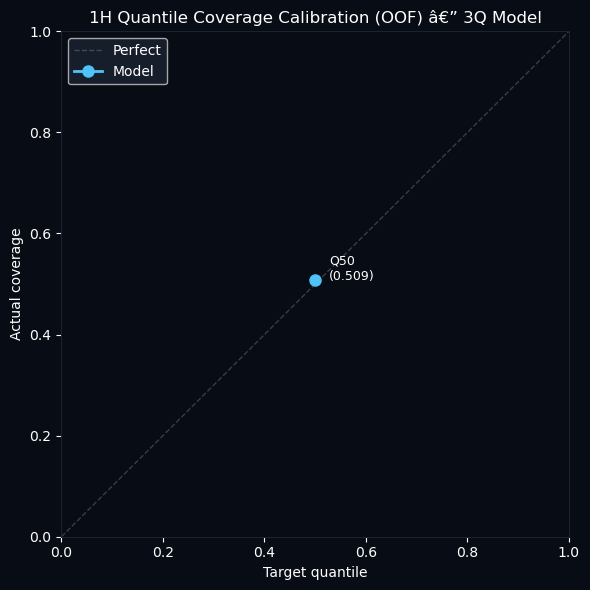

In [62]:
valid_oof = ~np.isnan(oof_preds[QUANTILES[0]])
y_oof = y_clean.values[valid_oof]

print(f'OOF Quantile Coverage:')
print(f'{"Quantile":<10} {"Target":<10} {"Actual":<10} {"Gap"}')
print(f'{"-"*42}')

for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
    preds_oof = oof_preds[q][valid_oof]
    coverage  = np.mean(y_oof <= preds_oof)
    gap       = coverage - q
    flag      = 'OK' if abs(gap) < 0.03 else 'NEEDS CALIBRATION'
    print(f'{q_name:<10} {q:<10.2f} {coverage:<10.3f} {gap:+.3f}  {flag}')

# Calibration plot
fig, ax = plt.subplots(figsize=(6, 6))
fig.patch.set_facecolor('#080c14')
ax.set_facecolor('#080c14')

targets = QUANTILES
actuals = [np.mean(y_oof <= oof_preds[q][valid_oof]) for q in QUANTILES]

ax.plot([0,1], [0,1], '--', color=(1,1,1,0.2), linewidth=1, label='Perfect')
ax.plot(targets, actuals, 'o-', color='#4fc3f7', linewidth=2, markersize=8, label='Model')
for t, a, name in zip(targets, actuals, QUANTILE_NAMES):
    ax.annotate(f'{name}\n({a:.3f})', (t, a), textcoords='offset points',
                xytext=(10, 0), color='white', fontsize=9)

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel('Target quantile', color='white')
ax.set_ylabel('Actual coverage', color='white')
ax.set_title('1H Quantile Coverage Calibration (OOF) â€” 3Q Model', color='white')
ax.tick_params(colors='white')
ax.legend(facecolor='#1a2332', labelcolor='white')
for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')
plt.tight_layout()
plt.show()

## 6. Test Set Evaluation

Load final model, predict Q50 on unseen test set.

**Interpretation:**
- Q50 = predicted magnitude of move in pips (always positive)
- Higher Q50 = model expects a larger move
- Direction is handled separately


In [63]:
# Prepare test data
X_test = df_test[feature_cols].ffill().fillna(0)
y_test = df_test[TARGET_COL]
valid_test = y_test.notna()
X_test_clean = X_test[valid_test]
y_test_clean = y_test[valid_test]

bundle = joblib.load(MODELS_DIR / "model_1H_Q50.joblib")
q50_preds = bundle["model"].predict(X_test_clean)
print(f"Q50: mean={q50_preds.mean():.2f}, std={q50_preds.std():.2f}")

results = pd.DataFrame({
    "actual": y_test_clean.values,
    "Q50":    q50_preds,
    "pair":   df_test.loc[valid_test, "pair"].values,
}, index=y_test_clean.index)

print(f"\nTest rows: {len(results):,}")

# Per-threshold: how well does Q50 predict magnitude?
print(f"\nMFE Capture by Q50 Threshold:")
print(f"{'Q50 thresh':>12} {'N':>8} {'% kept':>7} {'Avg Q50':>10} {'Avg actual':>12} {'Capture%':>10} {'Corr':>7}")
print('-' * 72)
for thresh in [0, 10, 20, 30, 50, 70, 100, 150]:
    mask = results["Q50"] >= thresh
    if mask.sum() < 10: continue
    s = results[mask]
    capture = s["actual"].mean() / s["Q50"].mean() * 100
    corr = np.corrcoef(s["actual"], s["Q50"])[0, 1]
    print(f"{thresh:>12} {mask.sum():>8,} {mask.mean():>7.1%} {s['Q50'].mean():>10.1f} "
          f"{s['actual'].mean():>12.1f} {capture:>9.1f}% {corr:>7.3f}")


Q50: mean=43.35, std=25.89

Test rows: 136,372

MFE Capture by Q50 Threshold:
  Q50 thresh        N  % kept    Avg Q50   Avg actual   Capture%    Corr
------------------------------------------------------------------------
           0  136,372  100.0%       43.3         59.5     137.3%   0.443
          10  136,372  100.0%       43.3         59.5     137.3%   0.443
          20  125,155   91.8%       45.6         62.9     137.9%   0.432
          30   87,088   63.9%       54.7         76.1     139.3%   0.407
          50   38,448   28.2%       74.4        105.4     141.6%   0.403
          70   14,848   10.9%       99.4        150.7     151.7%   0.369
         100    5,327    3.9%      132.9        217.4     163.6%   0.296
         150    1,465    1.1%      173.5        307.4     177.2%   0.310


In [64]:
# Per-pair breakdown at Q50 > 30
filtered = results[results["Q50"] > 30]

print(f"Per-pair results (Q50 > 30):")
print(f"{'Pair':<10} {'N':>8} {'Avg actual MFE':>16} {'Avg Q50':>10} {'Corr':>7}")
print('-' * 55)
for pair in sorted(filtered["pair"].unique()):
    p = filtered[filtered["pair"] == pair]
    corr = np.corrcoef(p["actual"], p["Q50"])[0, 1] if len(p) > 10 else 0
    print(f"{pair:<10} {len(p):>8,} {p['actual'].mean():>16.2f} {p['Q50'].mean():>10.2f} {corr:>7.3f}")


Per-pair results (Q50 > 30):
Pair              N   Avg actual MFE    Avg Q50    Corr
-------------------------------------------------------
AUDJPY        7,827            63.12      49.47   0.507
AUDNZD        9,050            85.52      46.64   0.392
AUDUSD        1,393            59.77      43.72   0.325
CADJPY        7,737            73.22      52.85   0.438
CHFJPY        9,116           123.15      79.91   0.489
EURAUD        9,112            82.97      55.91   0.364
EURGBP        1,230            92.96      45.41   0.387
EURJPY        8,972            66.01      55.60   0.378
EURUSD        2,857            46.06      39.38   0.414
GBPJPY        9,012            75.71      67.36   0.579
GBPUSD        5,154            44.06      37.94   0.360
NZDUSD        1,762           105.93      51.38   0.277
USDCAD        3,473            78.06      47.11   0.231
USDCHF        1,844            54.08      43.68   0.183
USDJPY        8,549            61.89      51.22   0.517


## 7. Equity Curves

In [65]:
# MFE lift by Q50 decile
results['q50_decile'] = pd.qcut(results['Q50'], q=10, labels=False, duplicates='drop')
decile_stats = results.groupby('q50_decile').agg(
    trades=('actual', 'count'),
    avg_actual_mfe=('actual', 'mean'),
    avg_pred_mfe=('Q50', 'mean')
).reset_index()

print(f'{"Decile":>8} {"Trades":>8} {"Avg Pred MFE":>14} {"Avg Actual MFE":>16}')
print('-' * 50)
for _, row in decile_stats.iterrows():
    bar = '#' * int(row.avg_actual_mfe / 5)
    print(f'{int(row.q50_decile):>8} {int(row.trades):>8} {row.avg_pred_mfe:>14.1f} {row.avg_actual_mfe:>16.1f}  {bar}')
print('\nDecile 0 = lowest predicted MFE, Decile 9 = highest')

  Decile   Trades   Avg Pred MFE   Avg Actual MFE
--------------------------------------------------
       0    13638           18.6             22.7  ####
       1    13637           22.4             27.6  #####
       2    13637           25.8             34.6  ######
       3    13637           29.5             41.0  ########
       4    13637           34.2             47.9  #########
       5    13637           39.0             50.8  ##########
       6    13637           45.2             61.0  ############
       7    13637           52.8             70.6  ##############
       8    13637           64.0             84.0  ################
       9    13638          101.9            155.1  ###############################

Decile 0 = lowest predicted MFE, Decile 9 = highest


## 8. Feature Importance

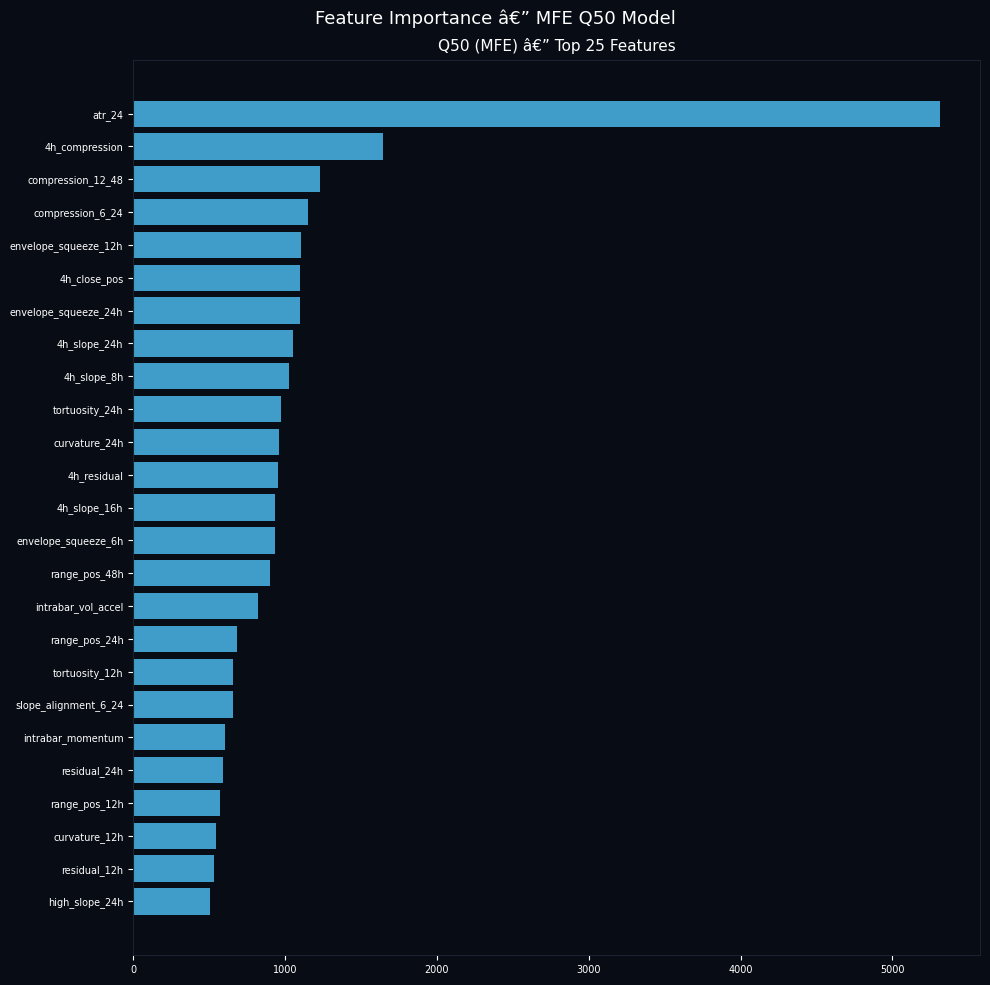

In [66]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
fig.patch.set_facecolor('#080c14')
ax.set_facecolor('#080c14')

bundle = joblib.load(MODELS_DIR / 'model_1H_Q50.joblib')
importance = pd.Series(bundle['model'].feature_importances_, index=feature_cols)
importance = importance.sort_values(ascending=True).tail(25)

ax.barh(importance.index, importance.values, color='#4fc3f7', alpha=0.8)
ax.tick_params(colors='white', labelsize=7)
ax.set_title('Q50 (MFE) â€” Top 25 Features', color='white', fontsize=11)
for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

plt.suptitle('Feature Importance â€” MFE Q50 Model', color='white', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Diagnostics

Q50 coverage: 0.504 (target: 0.50)
Mean actual MFE: 59.52 pips
Mean pred   MFE: 43.35 pips
Correlation:     0.443


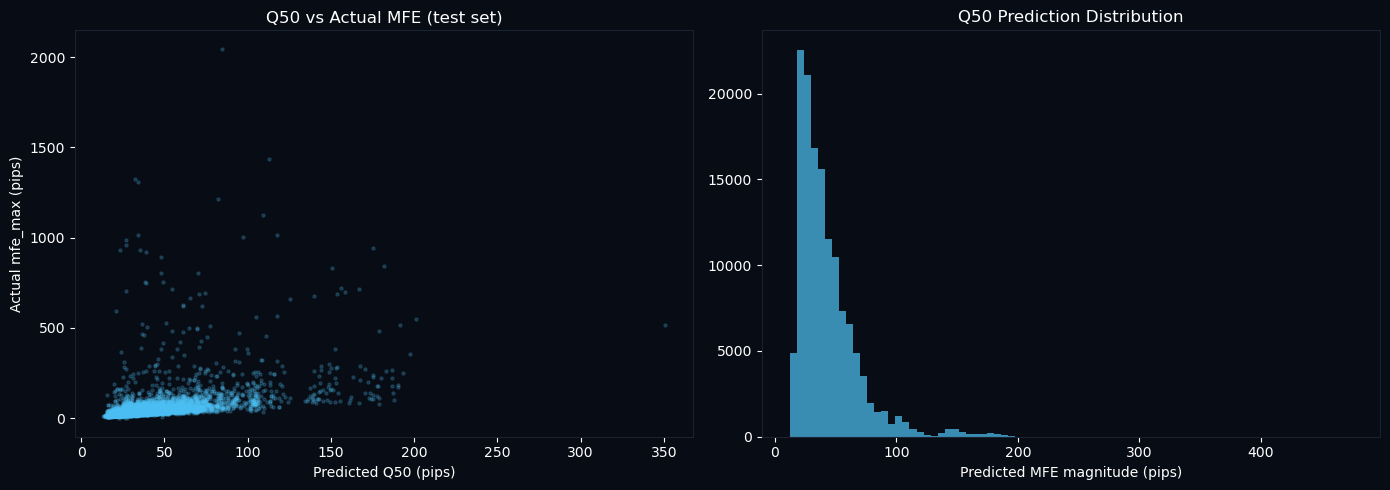

In [67]:
# Q50 coverage and correlation
coverage = (results["actual"] <= results["Q50"]).mean()
corr = np.corrcoef(results["actual"], results["Q50"])[0, 1]
print(f"Q50 coverage: {coverage:.3f} (target: 0.50)")
print(f"Mean actual MFE: {results['actual'].mean():.2f} pips")
print(f"Mean pred   MFE: {results['Q50'].mean():.2f} pips")
print(f"Correlation:     {corr:.3f}")

# Scatter: Q50 vs actual mfe_max
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#080c14")
for ax in axes:
    ax.set_facecolor("#080c14")
    ax.tick_params(colors="white")
    for spine in ax.spines.values(): spine.set_edgecolor("#1a2332")

sample = results.sample(min(5000, len(results)), random_state=42)
axes[0].scatter(sample["Q50"], sample["actual"], alpha=0.2, s=5, color="#4fc3f7")
axes[0].set_title("Q50 vs Actual MFE (test set)", color="white")
axes[0].set_xlabel("Predicted Q50 (pips)", color="white")
axes[0].set_ylabel("Actual mfe_max (pips)", color="white")

axes[1].hist(results["Q50"], bins=80, color="#4fc3f7", alpha=0.7, edgecolor="none")
axes[1].set_title("Q50 Prediction Distribution", color="white")
axes[1].set_xlabel("Predicted MFE magnitude (pips)", color="white")

plt.tight_layout()
plt.show()


## 11. Summary

In [68]:
print("=" * 70)
print("MFE GEOMETRIC MODEL — TRAINING COMPLETE")
print("=" * 70)

print(f"\nModels saved to: {MODELS_DIR.resolve()}")
for f in sorted(MODELS_DIR.glob("*.joblib")):
    print(f"  {f.name:<25} {f.stat().st_size / 1024 / 1024:.1f} MB")

print(f"\n-- CV Results --")
for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
    print(f"  {q_name}: pinball={np.mean(cv_pinball[q]):.6f}, avg_iters={int(np.mean(best_iters[q]))}")

print(f"\n-- Test Set (after {TRAIN_END}) --")
print(f"  Rows:             {len(results):,}")
print(f"  Q50 coverage:     {(results['actual'] <= results['Q50']).mean():.3f} (target 0.50)")
print(f"  Mean actual MFE:  {results['actual'].mean():.2f} pips")
print(f"  Mean pred   MFE:  {results['Q50'].mean():.2f} pips")
print(f"  Corr:             {np.corrcoef(results['actual'], results['Q50'])[0,1]:.3f}")
print(f"  Signals Q50>30:   {(results['Q50']>30).sum():,}")
print(f"  Signals Q50>50:   {(results['Q50']>50).sum():,}")
print(f"  Signals Q50>70:   {(results['Q50']>70).sum():,}")


MFE GEOMETRIC MODEL — TRAINING COMPLETE

Models saved to: C:\Users\noual\lumeny\backend\models_9\mfe_geom
  model_1H_Q50.joblib       3.4 MB

-- CV Results --
  Q50: pinball=8.225852, avg_iters=637

-- Test Set (after 2024-06-30) --
  Rows:             136,372
  Q50 coverage:     0.504 (target 0.50)
  Mean actual MFE:  59.52 pips
  Mean pred   MFE:  43.35 pips
  Corr:             0.443
  Signals Q50>30:   87,088
  Signals Q50>50:   38,448
  Signals Q50>70:   14,848


In [69]:
# Signal distribution by hour and pair (Q50 > 50)
sub = results[results["Q50"] > 50].copy()
sub["hour"] = sub.index.hour

by_hour = sub.groupby("hour").agg(
    n=('actual', 'count'),
    avg_actual=('actual', 'mean'),
    avg_pred=('Q50', 'mean')
)
total = by_hour["n"].sum()
print(f"Signal distribution by hour (Q50>50), total={int(total):,}:")
print(f"{'Hour':>5} {'N':>7} {'%':>6} {'Avg pred':>10} {'Avg actual':>12}")
print('-' * 45)
for hour, row in by_hour.iterrows():
    bar = '#' * int(row["n"] / total * 40)
    print(f"{hour:>5} {int(row['n']):>7} {row['n']/total:>6.1%} {row['avg_pred']:>10.1f} {row['avg_actual']:>12.1f}  {bar}")

print(f"\nSignal distribution by pair (Q50>50):")
by_pair = sub.groupby("pair").agg(
    n=('actual', 'count'),
    avg_pred=('Q50', 'mean'),
    avg_actual=('actual', 'mean')
).sort_values("n", ascending=False)
print(by_pair.to_string())


Signal distribution by hour (Q50>50), total=38,448:
 Hour       N      %   Avg pred   Avg actual
---------------------------------------------
    0    1608   4.2%       74.3         95.0  #
    1    1610   4.2%       73.9         96.5  #
    2    1616   4.2%       73.9         96.6  #
    3    1601   4.2%       74.0         95.9  #
    4    1601   4.2%       74.3         94.9  #
    5    1595   4.1%       74.3         96.7  #
    6    1603   4.2%       74.4         98.3  #
    7    1621   4.2%       74.3         98.4  #
    8    1649   4.3%       74.2         96.9  #
    9    1630   4.2%       74.1         97.4  #
   10    1629   4.2%       73.8         95.7  #
   11    1635   4.3%       73.7         95.9  #
   12    1617   4.2%       73.2         99.3  #
   13    1611   4.2%       73.5        103.6  #
   14    1634   4.2%       73.6        115.0  #
   15    1642   4.3%       73.8        119.8  #
   16    1641   4.3%       73.9        122.8  #
   17    1655   4.3%       73.8        12

In [70]:
# MFE magnitude lift: does higher Q50 actually mean larger actual move?
# Decile analysis
results["q50_decile"] = pd.qcut(results["Q50"], q=10, labels=False, duplicates="drop")
decile_stats = results.groupby("q50_decile").agg(
    n=('actual', 'count'),
    avg_pred=('Q50', 'mean'),
    avg_actual=('actual', 'mean')
).reset_index()

print(f"{'Decile':>8} {'N':>8} {'Avg Q50':>10} {'Avg actual':>12}")
print('-' * 45)
for _, row in decile_stats.iterrows():
    bar = '#' * int(row.avg_actual / 5)
    print(f"{int(row.q50_decile):>8} {int(row.n):>8} {row.avg_pred:>10.1f} {row.avg_actual:>12.1f}  {bar}")
print('\nDecile 0 = lowest Q50, Decile 9 = highest Q50')

# Threshold table: avg actual MFE when Q50 > threshold
print(f"\nActual MFE realized when model says Q50 > threshold:")
print(f"{'Q50 thresh':>12} {'N':>8} {'% kept':>7} {'Avg Q50':>10} {'Avg actual':>12} {'Capture%':>10} {'Corr':>7}")
print('-' * 72)
for thresh in [0, 20, 30, 50, 70, 100, 150]:
    mask = results["Q50"] >= thresh
    if mask.sum() < 10: continue
    s = results[mask]
    capture = s["actual"].mean() / s["Q50"].mean() * 100
    corr = np.corrcoef(s["actual"], s["Q50"])[0, 1]
    print(f"{thresh:>12} {mask.sum():>8,} {mask.mean():>7.1%} {s['Q50'].mean():>10.1f} "
          f"{s['actual'].mean():>12.1f} {capture:>9.1f}% {corr:>7.3f}")


  Decile        N    Avg Q50   Avg actual
---------------------------------------------
       0    13638       18.6         22.7  ####
       1    13637       22.4         27.6  #####
       2    13637       25.8         34.6  ######
       3    13637       29.5         41.0  ########
       4    13637       34.2         47.9  #########
       5    13637       39.0         50.8  ##########
       6    13637       45.2         61.0  ############
       7    13637       52.8         70.6  ##############
       8    13637       64.0         84.0  ################
       9    13638      101.9        155.1  ###############################

Decile 0 = lowest Q50, Decile 9 = highest Q50

Actual MFE realized when model says Q50 > threshold:
  Q50 thresh        N  % kept    Avg Q50   Avg actual   Capture%    Corr
------------------------------------------------------------------------
           0  136,372  100.0%       43.3         59.5     137.3%   0.443
          20  125,155   91.8%       4

In [71]:
# Per-pair actual MFE realized at Q50>30 and Q50>50
for thresh in [30, 50, 70]:
    sub = results[results["Q50"] >= thresh]
    print(f"\nPer-pair at Q50>={thresh} (N={len(sub):,}):")
    print(f"{'Pair':<10} {'N':>6} {'Avg Q50':>10} {'Avg actual':>12} {'Capture%':>10} {'Corr':>7}")
    print('-' * 58)
    for pair, g in sub.groupby("pair"):
        if len(g) < 5: continue
        capture = g["actual"].mean() / g["Q50"].mean() * 100
        corr = np.corrcoef(g["actual"], g["Q50"])[0, 1] if len(g) > 10 else 0
        print(f"{pair:<10} {len(g):>6,} {g['Q50'].mean():>10.1f} {g['actual'].mean():>12.1f} {capture:>9.1f}% {corr:>7.3f}")



Per-pair at Q50>=30 (N=87,088):
Pair            N    Avg Q50   Avg actual   Capture%    Corr
----------------------------------------------------------
AUDJPY      7,827       49.5         63.1     127.6%   0.507
AUDNZD      9,050       46.6         85.5     183.4%   0.392
AUDUSD      1,393       43.7         59.8     136.7%   0.325
CADJPY      7,737       52.9         73.2     138.5%   0.438
CHFJPY      9,116       79.9        123.1     154.1%   0.489
EURAUD      9,112       55.9         83.0     148.4%   0.364
EURGBP      1,230       45.4         93.0     204.7%   0.387
EURJPY      8,972       55.6         66.0     118.7%   0.378
EURUSD      2,857       39.4         46.1     117.0%   0.414
GBPJPY      9,012       67.4         75.7     112.4%   0.579
GBPUSD      5,154       37.9         44.1     116.1%   0.360
NZDUSD      1,762       51.4        105.9     206.2%   0.277
USDCAD      3,473       47.1         78.1     165.7%   0.231
USDCHF      1,844       43.7         54.1     123.8%  